In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q "/content/drive/MyDrive/2413-Sanket-Naik-Dissertation-2025-26/KaggleDataset/ISICDataset.zip" -d "/content/data/"
print("Extrated files")

Extrated files


Fixed Grad CAM

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
from torchvision import models
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import pandas as pd

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=None)
model.fc = torch.nn.Linear(model.fc.in_features, 1)
model.load_state_dict(torch.load("best_resnet18_isic2024_weiighted_and_Augment.pth"))
model.to(DEVICE)
model.eval()

activations = None
gradients = None

def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

# Use FULL backward hook (important)
model.layer4.register_forward_hook(forward_hook)
model.layer4.register_full_backward_hook(backward_hook)


transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(),
    ToTensorV2()
])


def generate_gradcam(img_path):

    global activations, gradients

    image = np.array(Image.open(img_path).convert("RGB"))
    input_tensor = transform(image=image)["image"].unsqueeze(0).to(DEVICE)

    output = model(input_tensor)

    model.zero_grad()
    score = output.squeeze()
    score.backward()

    pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

    activations_local = activations.detach().clone()
    for i in range(pooled_gradients.shape[0]):
        activations_local[:, i, :, :] *= pooled_gradients[i]

    heatmap = torch.mean(activations_local, dim=1).squeeze()
    heatmap = F.relu(heatmap)

    if torch.max(heatmap) != 0:
        heatmap /= torch.max(heatmap)

    heatmap = heatmap.cpu().numpy()
    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))

    return image, heatmap


def show_gradcam(img_path):

    image, heatmap = generate_gradcam(img_path)

    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(image, 0.6, heatmap_color, 0.4, 0)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(image)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Heatmap")
    plt.imshow(heatmap, cmap="jet")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Overlay")
    plt.imshow(overlay)
    plt.axis("off")

    plt.show()

In [ ]:
from tqdm import tqdm

def get_predictions(df):

    preds = []
    probs = []

    for path in tqdm(df["path"].values):

        image = np.array(Image.open(path).convert("RGB"))
        input_tensor = transform(image=image)["image"].unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            output = model(input_tensor)
            prob = torch.sigmoid(output).item()

        probs.append(prob)
        preds.append(1 if prob >= 0.5 else 0)

    df = df.copy()
    df["prob"] = probs
    df["pred"] = preds

    return df

In [ ]:
val_df = pd.read_csv("/content/drive/MyDrive/2413-Sanket-Naik-Dissertation-2025-26/Implimentations/final_dataset_index.csv")
val_samples = val_df[val_df["split"] == "val"]

val_samples = get_predictions(val_samples)

100%|██████████| 53629/53629 [04:06<00:00, 217.76it/s]


In [ ]:
true_benign = val_samples[(val_samples["target"] == 0) & (val_samples["pred"] == 0)]

true_malignant = val_samples[(val_samples["target"] == 1) & (val_samples["pred"] == 1)]

false_positive = val_samples[(val_samples["target"] == 0) & (val_samples["pred"] == 1)]

false_negative = val_samples[(val_samples["target"] == 1) & (val_samples["pred"] == 0)]

True Benign | Prob: 0.15432873368263245


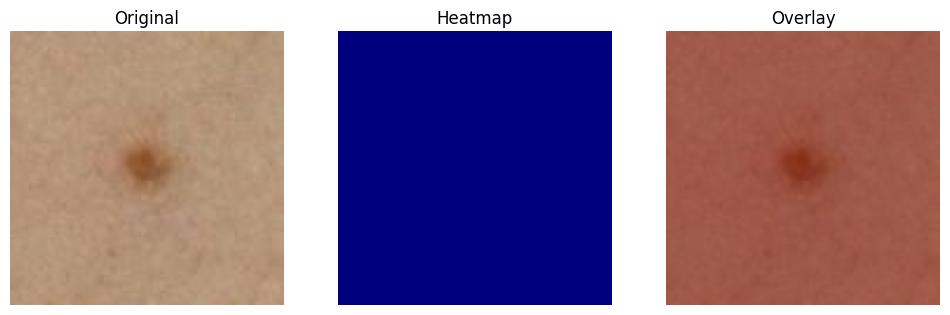

True Benign | Prob: 0.12320690602064133


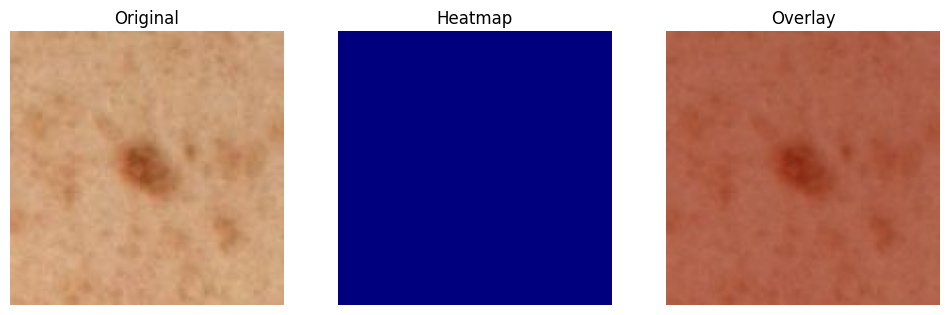

True Benign | Prob: 0.13943174481391907


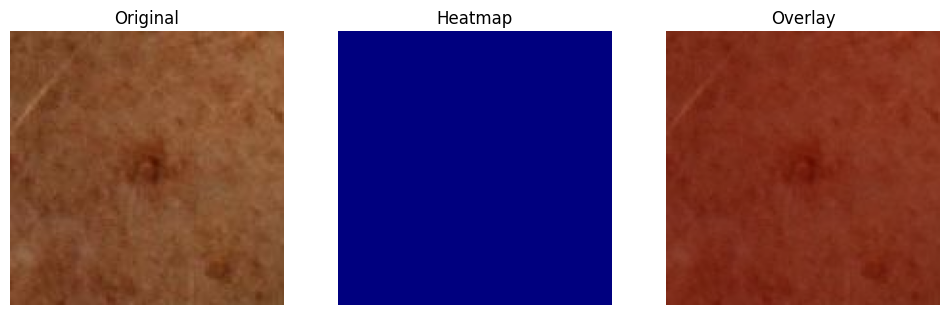

In [ ]:
for i in range(3):
    print("True Benign | Prob:", true_benign.iloc[i]["prob"])
    show_gradcam(true_benign.iloc[i]["path"])

True Malignant | Prob: 0.9996464252471924


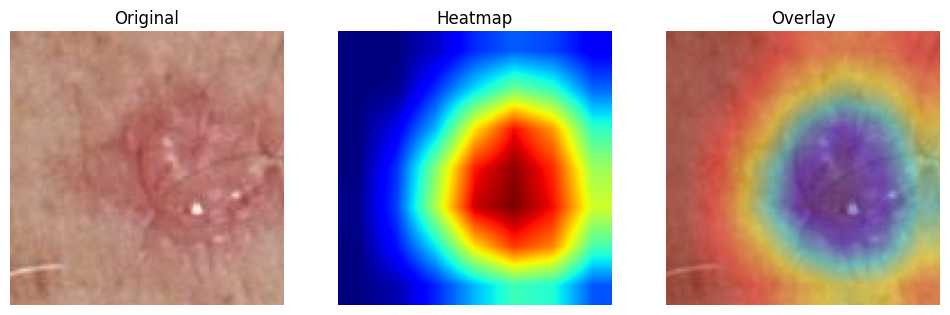

True Malignant | Prob: 0.9027387499809265


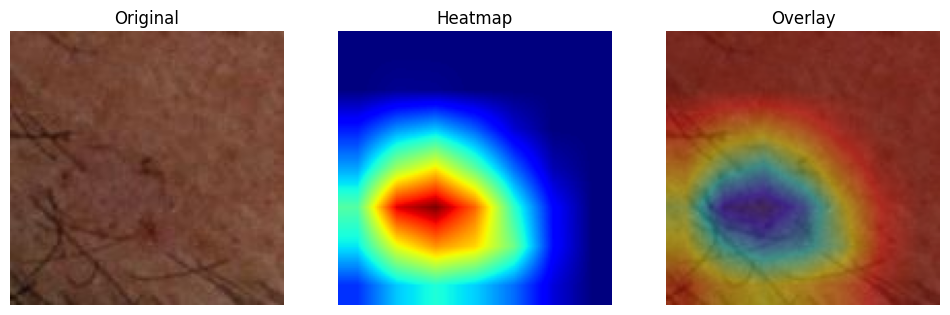

True Malignant | Prob: 0.9495913982391357


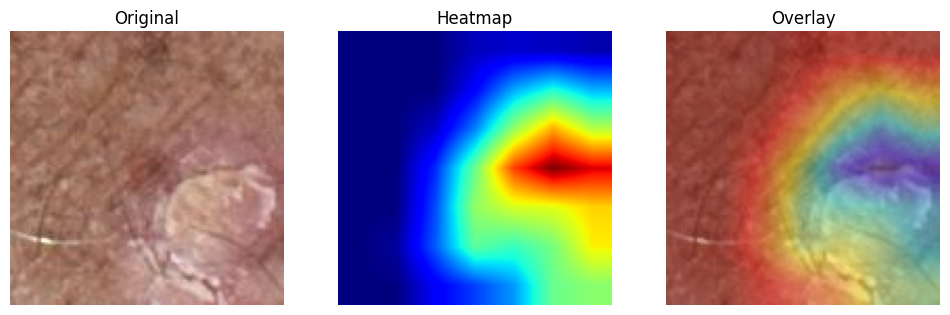

In [ ]:
for i in range(3):
    print("True Malignant | Prob:", true_malignant.iloc[i]["prob"])
    show_gradcam(true_malignant.iloc[i]["path"])

False Negative | Prob: 0.46622538566589355


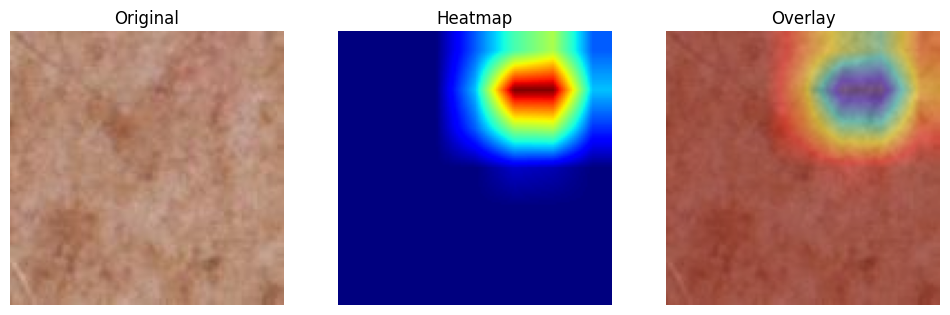

False Negative | Prob: 0.4595892131328583


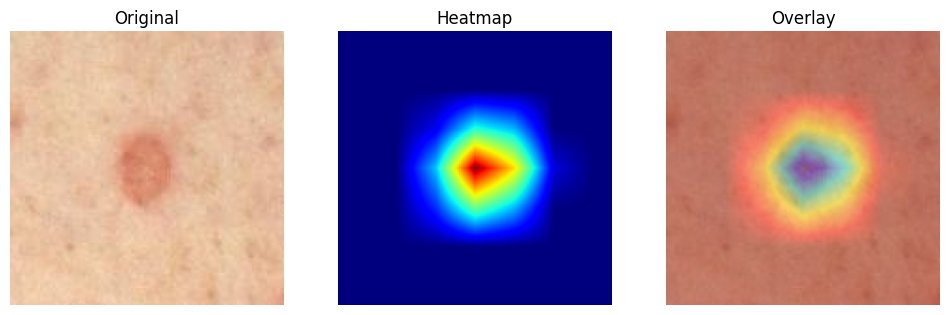

False Negative | Prob: 0.4240705072879791


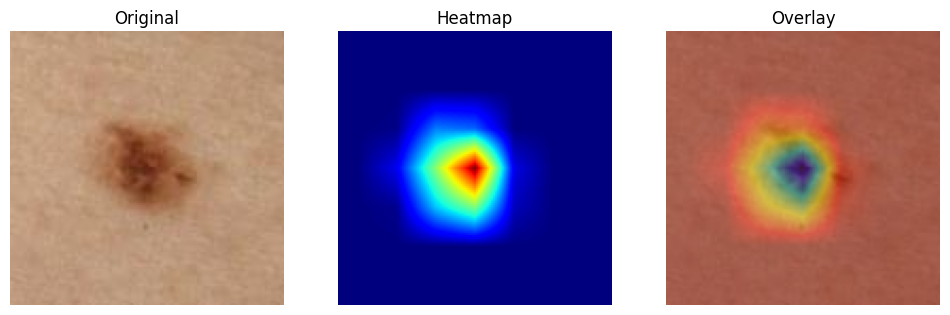

In [ ]:
for i in range(3):
    print("False Negative | Prob:", false_negative.iloc[i]["prob"])
    show_gradcam(false_negative.iloc[i]["path"])

False Positive | Prob: 0.9565635323524475


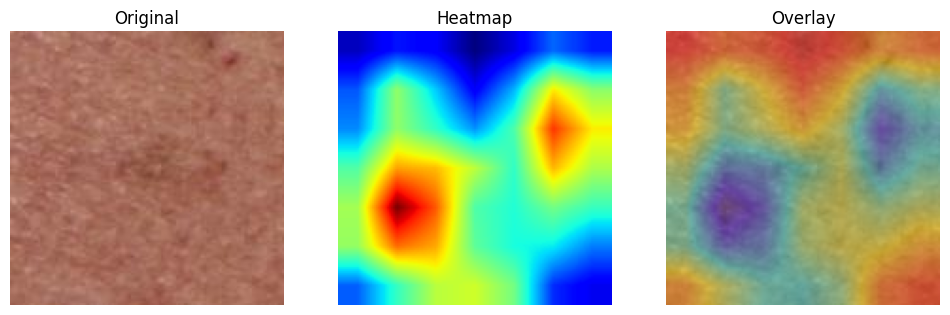

False Positive | Prob: 0.8308367729187012


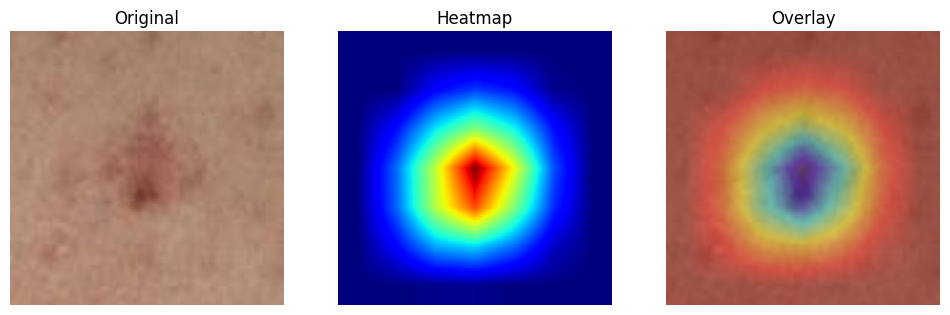

False Positive | Prob: 0.8564043045043945


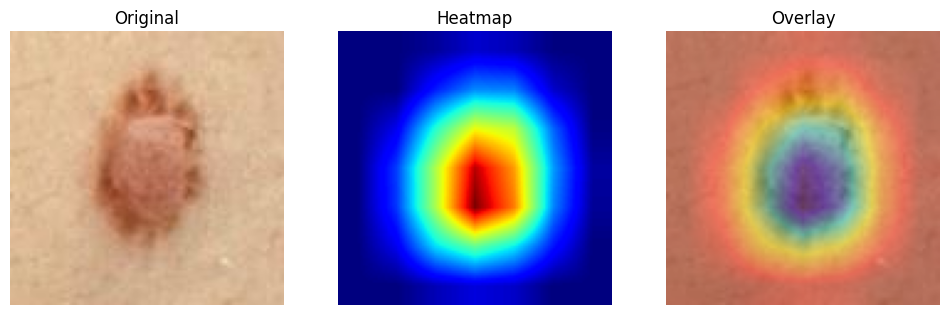

In [ ]:
for i in range(3):
    print("False Positive | Prob:", false_positive.iloc[i]["prob"])
    show_gradcam(false_positive.iloc[i]["path"])